-55.0


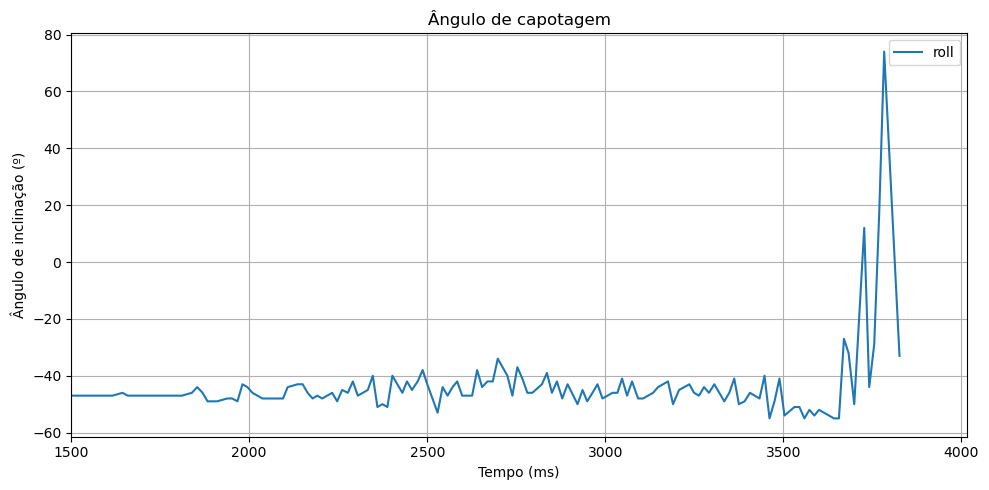

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data
file_path = r"C:\Users\tiago\OneDrive\0 LEF\3º ano\2S\Projeto Integrador\Ax Ay Az roll pitch time\angulo_tumble.txt"
ax, ay, az, roll, pitch, col, time = np.loadtxt(file_path, unpack=True)

# Combine into one array: [time, ax, ay, roll, pitch, col]
data = np.column_stack((time, ax, ay, roll, pitch, col))

# Find breakpoints where time resets
breaks = [0]
for i in range(1, len(time)):
    if time[i] < time[i - 1]:
        breaks.append(i)
breaks.append(len(time))

# Filter segments with time span >= 1000
valid_segments = []
for seg_num in range(len(breaks) - 1):
    start, end = breaks[seg_num], breaks[seg_num + 1]
    if np.abs(time[end - 1] - time[start]) >= 1000:
        valid_segments.append((start, end))

# Get only the last valid segment
if valid_segments:
    start, end = valid_segments[-1]
    segment = data[start:end]

    t = segment[:, 0]
    roll_seg = segment[:, 3]
    print(np.min(roll_seg))
    plt.figure(figsize=(10, 5))
    plt.plot(t, roll_seg, label='roll')
    plt.title('Ângulo de capotagem')
    plt.xlabel('Tempo (ms)')
    plt.ylabel('Ângulo de inclinação (º)')
    plt.grid(True)
    plt.legend()
    plt.xlim(1500)
    plt.tight_layout()
    plt.show()
else:
    print("No valid segments found.")


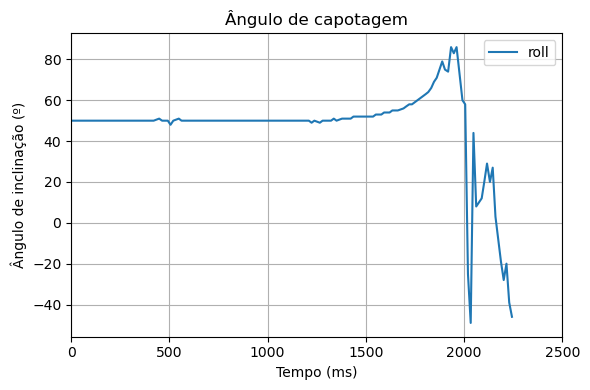

In [93]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data
file_path = r"C:\Users\tiago\OneDrive\0 LEF\3º ano\2S\Projeto Integrador\Ax Ay Az roll pitch time\tumble_parede.txt"
ax, ay, az, pitch, roll, col, time = np.loadtxt(file_path, unpack=True)

# Combine into one array: [time, ax, ay, roll, pitch, col]
data = np.column_stack((time, ax, ay, roll, pitch, col))

# Find breakpoints where time resets
breaks = [0]
for i in range(1, len(time)):
    if time[i] < time[i - 1]:
        breaks.append(i)
breaks.append(len(time))

# Filter segments with time span >= 1000
valid_segments = []
for seg_num in range(len(breaks) - 1):
    start, end = breaks[seg_num], breaks[seg_num + 1]
    if np.abs(time[end - 1] - time[start]) >= 1000:
        valid_segments.append((start, end))

# Get only the last valid segment
if valid_segments:
    start, end = valid_segments[-1]
    segment = data[start:end]

    t = segment[:, 0] - 44000
    roll_seg = segment[:, 3]
    plt.figure(figsize=(6, 4))
    plt.plot(t, roll_seg, label='roll')
    plt.title('Ângulo de capotagem')
    plt.xlabel('Tempo (ms)')
    plt.ylabel('Ângulo de inclinação (º)')
    plt.grid(True)
    plt.legend()
    plt.xlim(0, 2500)
    plt.tight_layout()
    plt.show()
else:
    print("No valid segments found.")


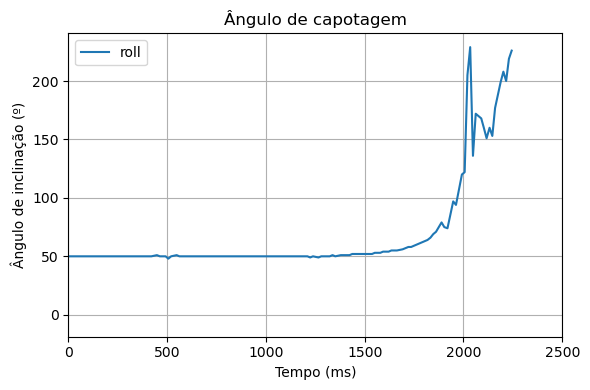

In [95]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data
file_path = r"C:\Users\tiago\OneDrive\0 LEF\3º ano\2S\Projeto Integrador\Ax Ay Az roll pitch time\tumble_parede.txt"
ax, ay, az, pitch, roll, col, time = np.loadtxt(file_path, unpack=True)

# Combine into one array: [time, ax, ay, roll, pitch, col]
data = np.column_stack((time, ax, ay, roll, pitch, col))

# Find breakpoints where time resets
breaks = [0]
for i in range(1, len(time)):
    if time[i] < time[i - 1]:
        breaks.append(i)
breaks.append(len(time))

# Filter segments with time span >= 1000
valid_segments = []
for seg_num in range(len(breaks) - 1):
    start, end = breaks[seg_num], breaks[seg_num + 1]
    if np.abs(time[end - 1] - time[start]) >= 1000:
        valid_segments.append((start, end))

# Get only the last valid segment
if valid_segments:
    start, end = valid_segments[-1]
    segment = data[start:end]

    t = segment[:, 0] - 44000
    roll_seg = segment[:, 3].copy()

    # Encontrar o índice do valor máximo de roll
    idx_max = np.argmax(roll_seg)

    # Substituir todos os valores após o máximo por 180 - valor
    roll_seg[idx_max + 1:] = 180 - roll_seg[idx_max + 1:]

    # Plot
    plt.figure(figsize=(6, 4))
    plt.plot(t, roll_seg, label='roll')
    plt.title('Ângulo de capotagem')
    plt.xlabel('Tempo (ms)')
    plt.ylabel('Ângulo de inclinação (º)')
    plt.grid(True)
    plt.legend()
    plt.xlim(0, 2500)
    plt.tight_layout()
    plt.show()
else:
    print("No valid segments found.")
